In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv("BIKE DETAILS.csv")
df

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0


In [5]:
df.head(10)

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
5,Honda CB Twister,18000,2010,Individual,1st owner,60000,53857.0
6,Honda CB Hornet 160R,78500,2018,Individual,1st owner,17000,87719.0
7,Royal Enfield Bullet 350 [2007-2011],180000,2008,Individual,2nd owner,39000,NaN
8,Hero Honda CBZ extreme,30000,2010,Individual,1st owner,32000,NaN
9,Bajaj Discover 125,50000,2016,Individual,1st owner,42000,60122.0


In [6]:
df.columns

Index(['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven',
       'ex_showroom_price'],
      dtype='object')

In [7]:
df.shape

(1061, 7)

In [8]:
df.isnull().sum()

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

In [12]:
df.fillna('0',inplace=True)

In [13]:
df.isnull().sum()

name                 0
selling_price        0
year                 0
seller_type          0
owner                0
km_driven            0
ex_showroom_price    0
dtype: int64

<Axes: xlabel='selling_price', ylabel='Density'>

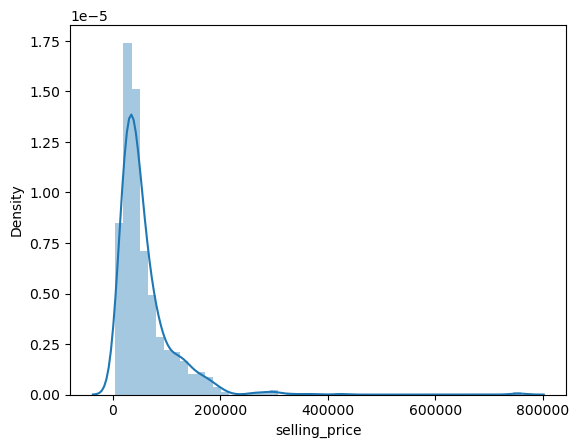

In [15]:
sns.distplot(df['selling_price'], kde=True)

In [28]:
df['selling_price'].mean()

np.float64(59638.151743638075)

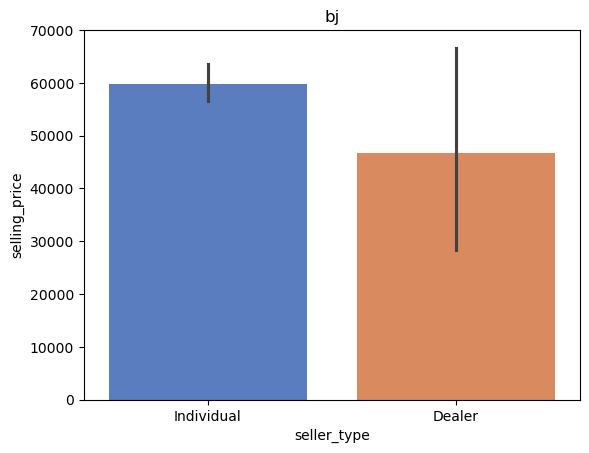

In [46]:
sns.barplot(x=df["seller_type"], y=df["selling_price"], palette='muted')
plt.title("av")
plt.show()

In [47]:
df.owner.value_counts()

owner
1st owner    924
2nd owner    123
3rd owner     11
4th owner      3
Name: count, dtype: int64

In [48]:
avg=df.groupby('owner')["km_driven"].mean().sort_values(ascending=False)
avg

owner
4th owner    311500.000000
2nd owner     39288.991870
3rd owner     33292.181818
1st owner     32816.583333
Name: km_driven, dtype: float64

<Axes: xlabel='owner', ylabel='km_driven'>

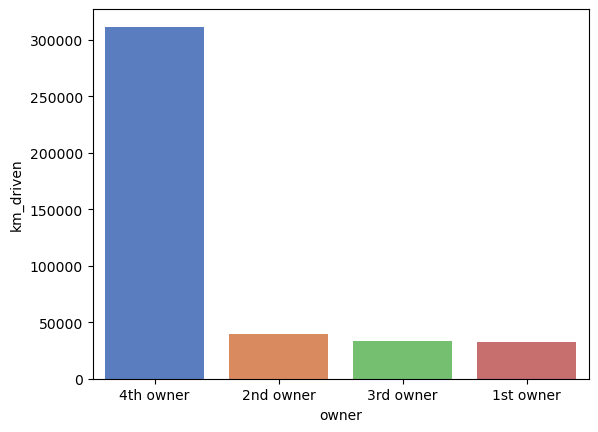

In [49]:
sns.barplot(avg,palette='muted')

In [51]:
df.describe()

,selling_price,year,km_driven
count,1061.000000,1061.000000,1061.000000
mean,59638.151744,2013.867107,34359.833176
std,56304.291973,4.301191,51623.152702
min,5000.000000,1988.000000,350.000000
25%,28000.000000,2011.000000,13500.000000
50%,45000.000000,2015.000000,25000.000000
75%,70000.000000,2017.000000,43000.000000
max,760000.000000,2020.000000,880000.000000


<Axes: >

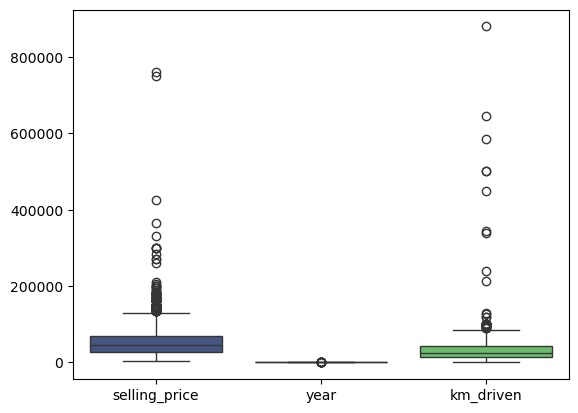

In [52]:
sns.boxplot(data=df,palette='viridis')

In [53]:
def detect_out(columns):
    outler_indices=[]
    for column in columns:
        Q1=df[column].quantile(0.25)
        Q3=df[column].quantile(0.75)
        IQR=Q3-Q1

        # Mask is a boolean condition 
        mask = (df[column] >= (Q1-1.5*IQR)) & (df[column] <= (Q3+1.5*IQR))
        mask=mask.to_numpy() # bool to nupy array

        # Find the indices of value that do not satisfy the mask condition -- that is a outlier 
        false_indices=np.argwhere(~mask)
        outler_indices.append(false_indices)
    return np.unique(np.concatenate(outler_indices).ravel())  